**Cell 1 — Imports and configuration**

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme

BASE_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

BAYER_CSV = os.path.join(BASE_DIR, "BAYN_DE_log_returns.csv")
BMW_CSV = os.path.join(BASE_DIR, "BMW_DE_log_returns.csv")
SIE_CSV = os.path.join(BASE_DIR, "SIE_DE_log_returns.csv")

BLOCK_SIZE = 20
N_TAIL = 100

**Cell 2 — Load and combine returns**

In [13]:
r_bayer = pd.read_csv(BAYER_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_bmw = pd.read_csv(BMW_CSV, parse_dates=["Date"]).set_index("Date")["Close"]
r_sie = pd.read_csv(SIE_CSV, parse_dates=["Date"]).set_index("Date")["Close"]

returns = pd.concat([r_bayer, r_bmw, r_sie], axis=1)
returns.columns = ["Bayer", "BMW", "Siemens"]
returns = returns.dropna()

print(f"Sample date range: {returns.index.min().date()} to {returns.index.max().date()}")
print(f"Total observations: {len(returns)}")

Sample date range: 1996-12-17 to 2026-05-04
Total observations: 7522


**Cell 3 — Equal-weighted portfolio returns**

In [14]:
b = np.array([1, 1, 1]) / 3
X = (returns @ b).values

**Cell 4 — Block maxima, top-100 tail selection**

In [15]:
n_blocks = len(X) // BLOCK_SIZE
blocks = X[:n_blocks * BLOCK_SIZE].reshape(n_blocks, BLOCK_SIZE)
block_maxima = blocks.max(axis=1)

tail_values = np.sort(block_maxima)[-N_TAIL:]
print(f"Using top {N_TAIL} of {n_blocks} block maxima")

Using top 100 of 376 block maxima


**Cell 5 — Fit GEV distribution**

In [16]:
c_fit, loc_fit, scale_fit = genextreme.fit(tail_values)
gamma = -c_fit

print(f"Fitted GEV: xi={gamma:.4f}, loc={loc_fit:.4f}, scale={scale_fit:.4f}")

Fitted GEV: xi=0.6946, loc=0.0413, scale=0.0067


**Cell 6 — Compute QQ-plot coordinates and reference line**

In [17]:
n = len(tail_values)
probs = (np.arange(1, n + 1) - 0.5) / n

empirical_q = np.sort(tail_values)
theoretical_q = genextreme.ppf(probs, c=c_fit, loc=loc_fit, scale=scale_fit)

q25_e = np.percentile(empirical_q, 25)
q75_e = np.percentile(empirical_q, 75)
q25_t = genextreme.ppf(0.25, c=c_fit, loc=loc_fit, scale=scale_fit)
q75_t = genextreme.ppf(0.75, c=c_fit, loc=loc_fit, scale=scale_fit)

slope = (q75_e - q25_e) / (q75_t - q25_t)
intercept = q25_e - slope * q25_t

x_line_qq = np.linspace(theoretical_q.min(), theoretical_q.max(), 200)
y_line_qq = slope * x_line_qq + intercept

**Cell 7 — Compute PP-plot coordinates**

In [18]:
# PP-plot: theoretical CDF of sorted empirical data vs. uniform plotting positions
empirical_p = np.sort(tail_values)
theoretical_p = genextreme.cdf(empirical_p, c=c_fit, loc=loc_fit, scale=scale_fit)

t_uniform = (np.arange(1, n + 1) - 0.5) / n

**Cell 8 — QQ-plot, display and save**

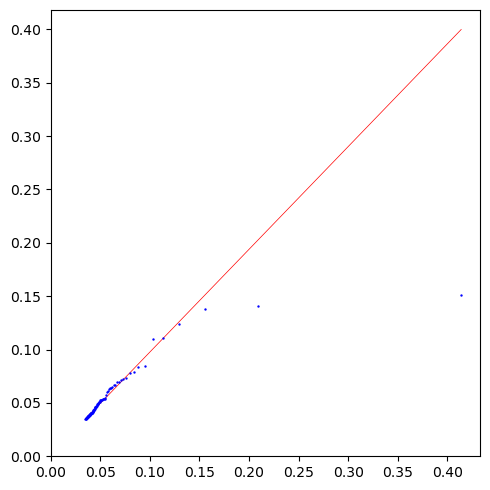

In [21]:
fig1, ax1 = plt.subplots(figsize=(5, 5))

ax1.scatter(theoretical_q, empirical_q, color="blue", s=0.5, zorder=3)
ax1.plot(x_line_qq, y_line_qq, color="red", linewidth=0.5, zorder=2)

ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)
ax1.grid(False)

fig1.patch.set_alpha(0)
ax1.patch.set_alpha(0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "qq_plot_GEV.png"), dpi=200, transparent=True, bbox_inches="tight")
plt.show()

**Cell 9 — PP-plot, display and save**

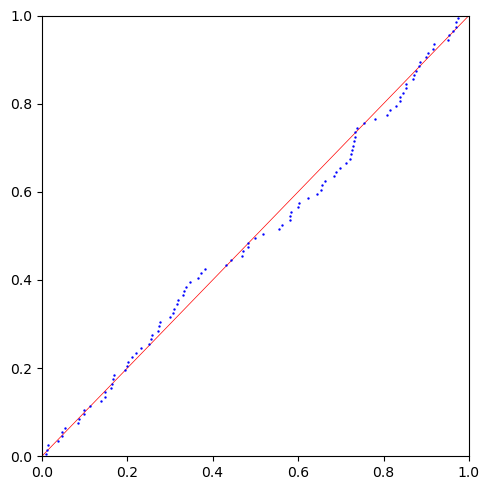

In [22]:
fig2, ax2 = plt.subplots(figsize=(5, 5))

ax2.scatter(theoretical_p, t_uniform, color="blue", s=0.5, zorder=3)
ax2.plot([0, 1], [0, 1], color="red", linewidth=0.5, zorder=2)

ax2.set_xlim(0, 1)
ax2.set_ylim(0, 1)
ax2.grid(False)

fig2.patch.set_alpha(0)
ax2.patch.set_alpha(0)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pp_plot_GEV.png"), dpi=200, transparent=True, bbox_inches="tight")
plt.show()